In [1]:
import pandas as pd
import os

In [4]:
genes_file = "/gpfs/commons/home/vmazeeva/gruyere-expr/tau_runs/joint_model_run_0/genes.txt"
genes = pd.read_csv(genes_file, header=None, sep='\t')
genes = genes.iloc[:, 1].tolist()

In [7]:
! pip install gprofiler-official

Defaulting to user installation because normal site-packages is not writeable


In [14]:
from gprofiler import GProfiler

gp = GProfiler(return_dataframe=True)

ensembl_ids = genes

# Convert Ensembl → gene symbols
mapping = gp.convert(
    organism="hsapiens",
    query=ensembl_ids,
    target_namespace="HGNC"
)

gene_symbols = mapping["converted"].dropna().astype(str).tolist()

enrichment = gp.profile(
    organism="hsapiens",
    query=gene_symbols
)


# Filter neuro / AD relevant terms
neuro_terms = enrichment[
    enrichment["name"].str.contains(
        "Alzheimer|neuro|brain|synapse|glia|neuron|cognition|dementia",
        case=False, na=False
    )
]

mapping, neuro_terms


(           incoming converted  n_incoming  n_converted      name  \
 0   ENSG00000173660     UQCRH           1            1     UQCRH   
 1   ENSG00000078018      MAP2           2            1      MAP2   
 2   ENSG00000166523    CLEC4E           3            1    CLEC4E   
 3   ENSG00000111684    LPCAT3           4            1    LPCAT3   
 4   ENSG00000164483     SAMD3           5            1     SAMD3   
 ..              ...       ...         ...          ...       ...   
 95  ENSG00000243789     JMJD7          96            1     JMJD7   
 96  ENSG00000163950      SLBP          97            1      SLBP   
 97  ENSG00000012171    SEMA3B          98            1    SEMA3B   
 98  ENSG00000141505     ASGR1          99            1     ASGR1   
 99  ENSG00000260456  C16orf95         100            1  C16orf95   
 
                                           description  \
 0   ubiquinol-cytochrome c reductase hinge protein...   
 1   microtubule associated protein 2 [Source:HGNC ...

In [11]:
enrichment

,source,native,name,p_value,significant,description,term_size,query_size,intersection_size,effective_domain_size,precision,recall,query,parents
0,GO:CC,GO:0099512,supramolecular fiber,0.002538,True,"""A polymer consisting of an indefinite number ...",1068,93,16,22149,0.172043,0.014981,query_1,[GO:0099081]
1,GO:CC,GO:0099081,supramolecular polymer,0.002786,True,"""A polymeric supramolecular structure."" [GOC:dos]",1076,93,16,22149,0.172043,0.014870,query_1,[GO:0099080]
2,GO:CC,GO:0005737,cytoplasm,0.015910,True,"""The contents of a cell excluding the plasma m...",12527,93,71,22149,0.763441,0.005668,query_1,"[GO:0005622, GO:0110165]"
3,GO:CC,GO:0099080,supramolecular complex,0.028673,True,"""A cellular component that consists of an inde...",1448,93,17,22149,0.182796,0.011740,query_1,[GO:0110165]


In [15]:
brain_genes = gp.profile(
    organism="hsapiens",
    query=gene_symbols,
    sources=["GO:BP"],
    all_results=True
)

brain_related = brain_genes[
    brain_genes["name"].str.contains(
        "synapse|neuron|brain|glia|axon|dendrite|cognition",
        case=False, na=False
    )
]


In [16]:
brain_related

,source,native,name,p_value,significant,description,term_size,query_size,intersection_size,effective_domain_size,precision,recall,query,parents
8,GO:BP,GO:0051402,neuron apoptotic process,1.0,False,"""Any apoptotic process in a neuron, the basic ...",296,92,2,21026,0.021739,0.006757,query_1,[GO:0006915]
103,GO:BP,GO:0050890,cognition,1.0,False,"""The operation of the mind by which an organis...",328,92,1,21026,0.010870,0.003049,query_1,[GO:0050877]
198,GO:BP,GO:0062207,regulation of pattern recognition receptor sig...,1.0,False,"""Any process that modulates the rate, frequenc...",172,92,2,21026,0.021739,0.011628,query_1,"[GO:0002221, GO:0009966, GO:0045088]"
199,GO:BP,GO:0062208,positive regulation of pattern recognition rec...,1.0,False,"""Any process that decreases the rate, frequenc...",71,92,1,21026,0.010870,0.014085,query_1,"[GO:0002221, GO:0009967, GO:0045089, GO:0062207]"
214,GO:BP,GO:0061452,retrotrapezoid nucleus neuron differentiation,1.0,False,"""The process in which a relatively unspecializ...",1,92,1,21026,0.010870,1.000000,query_1,"[GO:0021953, GO:0061451]"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2379,GO:BP,GO:0021953,central nervous system neuron differentiation,1.0,False,"""The process in which a relatively unspecializ...",215,92,3,21026,0.032609,0.013953,query_1,"[GO:0007417, GO:0030182]"
2380,GO:BP,GO:0021954,central nervous system neuron development,1.0,False,"""The process whose specific outcome is the pro...",94,92,2,21026,0.021739,0.021277,query_1,"[GO:0021953, GO:0048666]"
2381,GO:BP,GO:0021955,central nervous system neuron axonogenesis,1.0,False,"""Generation of a long process from a neuron wh...",38,92,1,21026,0.010870,0.026316,query_1,"[GO:0007409, GO:0021954]"
2424,GO:BP,GO:0010977,negative regulation of neuron projection devel...,1.0,False,"""Any process that decreases the rate, frequenc...",132,92,1,21026,0.010870,0.007576,query_1,"[GO:0010975, GO:0031175, GO:0031345]"


In [17]:
brain_terms = enrichment[
    enrichment["name"].str.contains(
        "neuron|brain|synapse|axon|dendrite|cognition",
        case=False, na=False
    )
]

gene_to_brain_terms = {}

for _, row in brain_terms.iterrows():
    for g in row["intersection"]:
        gene_to_brain_terms.setdefault(g, []).append(row["name"])

gene_to_brain_terms


{}

In [1]:
def read_pergene_regression_outputs(outdir):
    results_list = []
    for chrom in range(1,23):
        file = os.path.join(outdir, f"chr{chrom}_gene_association_results.csv")
        df = pd.read_csv(file)
        results_list.append(df)

    results = pd.concat(results_list, axis=0)   # vertically
    return results

In [4]:
outdir = "/gpfs/commons/home/vmazeeva/gruyere-expr/gene_association"
pvals = read_pergene_regression_outputs(outdir)["pval"].dropna().values

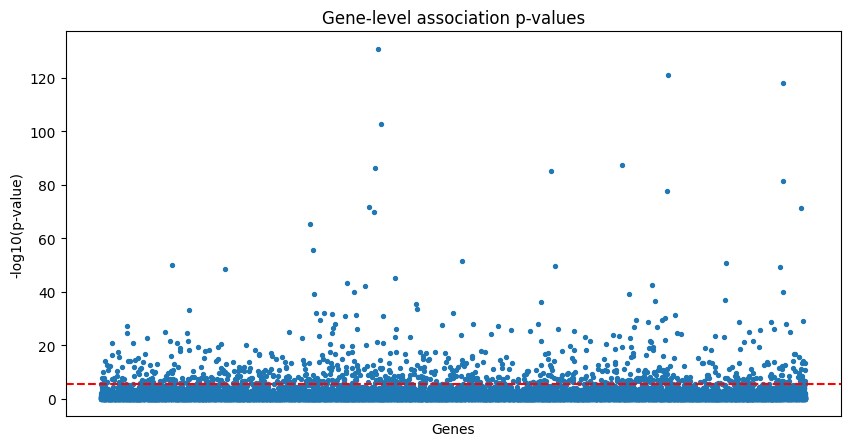

In [6]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(10,5))
plt.scatter(range(len(pvals)), -np.log10(pvals), s=8)
plt.axhline(-np.log10(0.05 / len(pvals)), color='red', linestyle='--')  # Bonferroni
plt.ylabel('-log10(p-value)')
plt.xlabel('Genes')
plt.xticks([])
plt.title(f'Gene-level association p-values')
plt.show()

In [52]:
import pandas as pd
import os

pergene_dir = "/gpfs/commons/home/vmazeeva/gruyere-expr/tau_runs_/joint_model_run_0/outputs/pergene_regression"

wgs = []

for chrom in range(1,23):
    file = os.path.join(pergene_dir, f"chr{chrom}_wgs.csv")
    df = pd.read_csv(file)
    wgs.append(df)

wgs_df = pd.concat(wgs, axis=0)
wgs_df.columns = ["gene", 'pval', 's2', 't_stat', 'coef', 'r2', 'fdr_qval']


In [3]:
wgs_df.head()


,gene,pval,s2,t_stat,coef,r2,fdr_qval
0,ENSG00000117016,0.255876,34.982730,-1.137528,-0.007624,0.891435,0.556032
1,ENSG00000158716,0.310571,9.224078,-1.015080,-0.008374,0.772241,0.616172
2,ENSG00000203965,0.011436,0.905040,2.538690,0.002470,0.823545,0.074884
3,ENSG00000058673,0.226191,6.841619,-1.211758,-0.006517,0.869473,0.516145
4,ENSG00000203740,0.580418,0.000146,-0.553144,-0.000011,0.100425,0.827857


In [53]:
wgs_df_sorted = wgs_df.sort_values(by="pval", ascending=True)



In [54]:
len(wgs_df)

18046

/scratch/ipykernel_2023431/999960327.py:7: RuntimeWarning: divide by zero encountered in log10
  plt.scatter(range(len(pvals)), -np.log10(pvals), s=8)


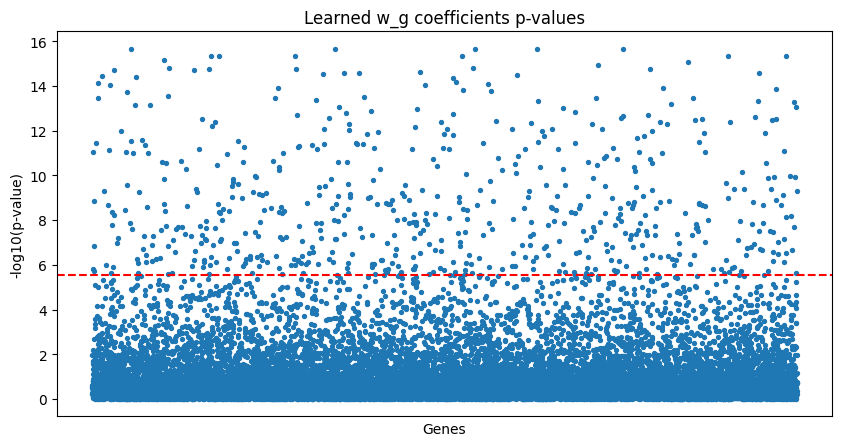

In [55]:
import matplotlib.pyplot as plt
import numpy as np

pvals = wgs_df["pval"].dropna().values

plt.figure(figsize=(10,5))
plt.scatter(range(len(pvals)), -np.log10(pvals), s=8)
plt.axhline(-np.log10(0.05 / len(pvals)), color='red', linestyle='--')  # Bonferroni
plt.ylabel('-log10(p-value)')
plt.xlabel('Genes')
plt.xticks([])
plt.title(f'Learned w_g coefficients p-values')
plt.show()

In [56]:
significant_wgs = wgs_df[wgs_df["pval"] < 0.05 / len(pvals)]
#significant_wgs = significant_wgs[significant_wgs["pval"] != 0]
significant_genes = list(significant_wgs["gene"])

In [57]:
len(significant_genes)

752

In [8]:
wgs_df["coef"].describe()

count    18046.000000
mean         0.000022
std          0.049278
min         -1.676758
25%         -0.000972
50%         -0.000002
75%          0.000774
max          3.176617
Name: coef, dtype: float64

In [36]:
wgs_df_filtered = wgs_df[wgs_df["coef"] != 0]

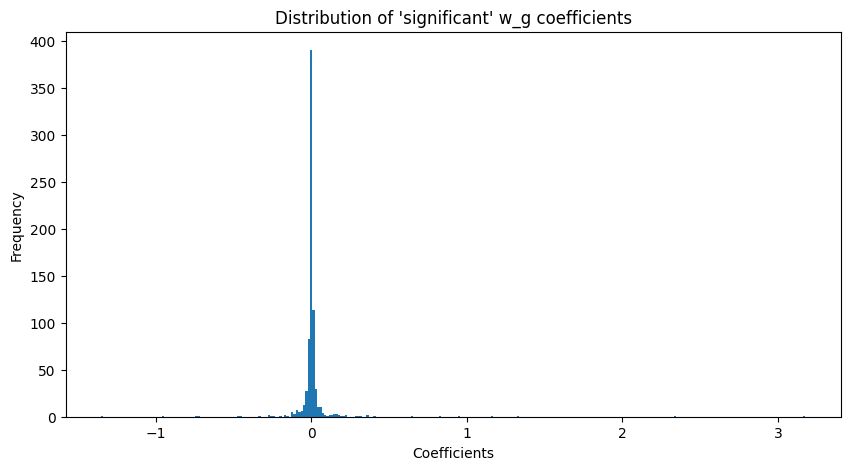

In [89]:
# distribution of coefficients
sig_coefs = significant_wgs["coef"].dropna().values
sig_coefs = sig_coefs[sig_coefs != 0]
plt.figure(figsize=(10,5))
plt.hist(sig_coefs, bins=300)
#plt.ylim(top=700)
plt.xlabel('Coefficients')
plt.ylabel('Frequency')
plt.title('Distribution of \'significant\' w_g coefficients')
plt.show()

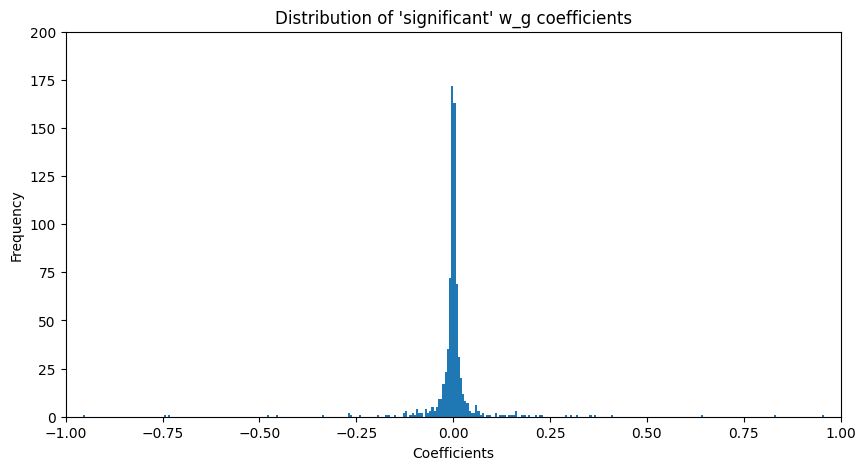

In [88]:
# distribution of coefficients
sig_coefs = significant_wgs["coef"].dropna().values
sig_coefs = sig_coefs[sig_coefs != 0]
plt.figure(figsize=(10,5))
plt.hist(sig_coefs, bins=800)
plt.ylim(top=200)
plt.xlim(-1,1)
plt.xlabel('Coefficients')
plt.ylabel('Frequency')
plt.title('Distribution of \'significant\' w_g coefficients')
plt.show()

In [11]:
wgs_df_filtered.head()

,gene,pval,s2,t_stat,coef,r2,fdr_qval
0,ENSG00000117016,0.255876,34.982730,-1.137528,-0.007624,0.891435,0.556032
1,ENSG00000158716,0.310571,9.224078,-1.015080,-0.008374,0.772241,0.616172
2,ENSG00000203965,0.011436,0.905040,2.538690,0.002470,0.823545,0.074884
3,ENSG00000058673,0.226191,6.841619,-1.211758,-0.006517,0.869473,0.516145
4,ENSG00000203740,0.580418,0.000146,-0.553144,-0.000011,0.100425,0.827857


In [61]:
from tqdm import tqdm

bs = []

for chrom in tqdm(range(1,23)):
    file = os.path.join(pergene_dir, f"chr{chrom}_betas.csv")
    df = pd.read_csv(file)
    bs.append(df)

bs_df = pd.concat(bs, axis=0)
bs_df.columns = ["variant", 'coef']


  0%|          | 0/22 [00:00<?, ?it/s]

100%|██████████| 22/22 [00:09<00:00,  2.27it/s]


In [63]:
bs_df.head

<bound method NDFrame.head of                               variant      coef
0        ENSG00000117016:1.40520857_A -0.002097
1        ENSG00000117016:1.40520863_A -0.001835
2        ENSG00000117016:1.40521475_T -0.003062
3        ENSG00000117016:1.40521576_T -0.005202
4        ENSG00000117016:1.40521629_A -0.001832
...                               ...       ...
299651  ENSG00000189269:22.23730069_C -0.000328
299652  ENSG00000189269:22.23730268_T -0.000237
299653  ENSG00000189269:22.23730719_A -0.000237
299654  ENSG00000189269:22.23731562_T -0.000495
299655  ENSG00000189269:22.23731753_T -0.000241

[12858810 rows x 2 columns]>

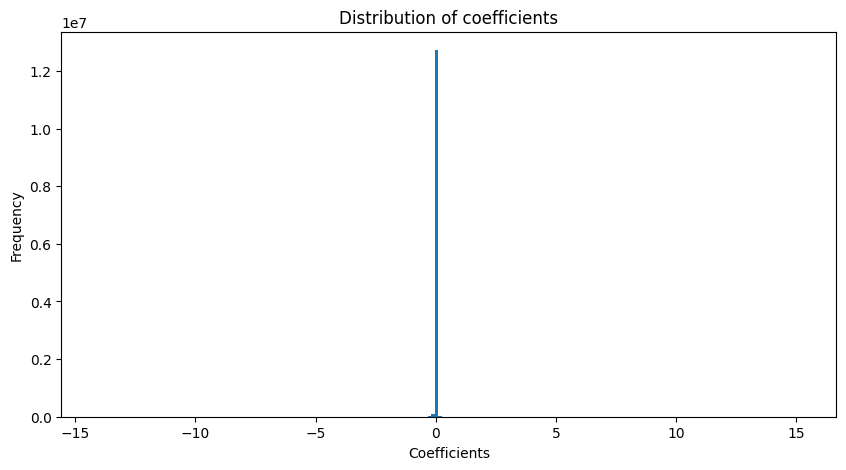

In [91]:
# distribution of coefficients
plt.figure(figsize=(10,5))
plt.hist(bs_df["coef"], bins=200)
# plt.ylim(top=200)
# plt.xlim(-1,1)
plt.xlabel('Coefficients')
plt.ylabel('Frequency')
plt.title('Distribution of coefficients')
plt.show()

In [92]:
bs_df.describe()

,coef
count,1.285881e+07
mean,-2.698271e-04
std,4.557554e-02
min,-1.411650e+01
25%,-3.697809e-04
50%,-6.156821e-07
75%,2.889175e-04
max,1.519611e+01


In [76]:
bs_sig_genes = []

for index, row in tqdm(bs_df.iterrows()):
    variant = row["variant"]
    gene = variant.split(":")[0]
    if gene in significant_genes:
        bs_sig_genes.append(row["coef"])

0it [00:00, ?it/s]

12858810it [16:26, 13031.09it/s]


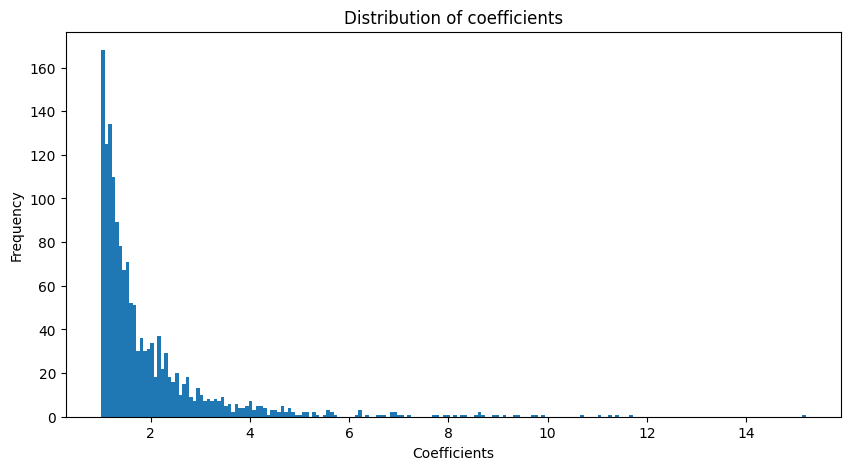

In [101]:
# distribution of coefficients
bs_sig_genes_1 = [x for x in bs_df["coef"] if x > 1]
plt.figure(figsize=(10,5))
plt.hist(bs_sig_genes_1, bins=200)
# plt.ylim(top=200)
# plt.xlim(-1,1)
plt.xlabel('Coefficients')
plt.ylabel('Frequency')
plt.title('Distribution of coefficients')
plt.show()

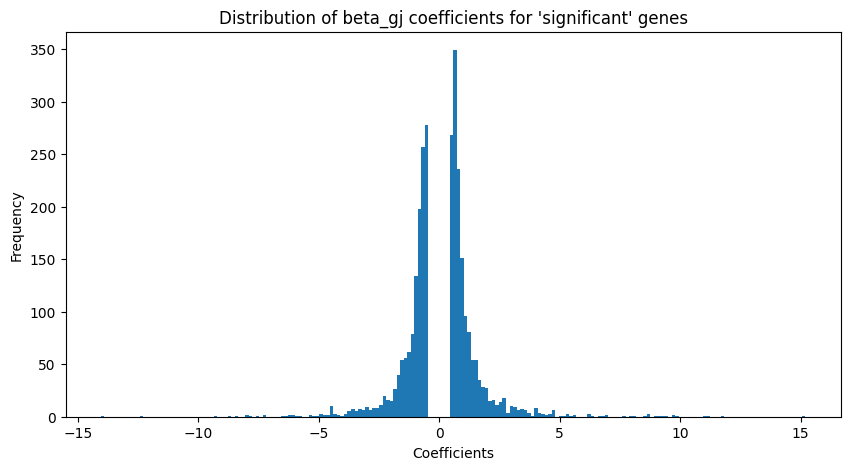

In [98]:
# distribution of coefficients
bs_sig_genes_1 = [x for x in bs_sig_genes if x < -0.5 or x>0.5]
plt.figure(figsize=(10,5))
plt.hist(bs_sig_genes_1, bins=200)
# plt.ylim(top=200)
# plt.xlim(-1,1)
plt.xlabel('Coefficients')
plt.ylabel('Frequency')
plt.title('Distribution of beta_gj coefficients for \'significant\' genes')
plt.show()

In [99]:
len(bs_sig_genes), len(bs_sig_genes_1)

(503047, 2916)

In [87]:
503047-1089

501958

In [78]:
len(bs_sig_genes), len(bs_df)

(503047, 12858810)